In [7]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy

import xarray as xr
from scipy.stats import kendalltau
#import seaborn as sns
from scipy.stats.mstats import theilslopes
import geopandas as gpd
import statsmodels.api as sm
import matplotlib.gridspec as gridspec

import pymannkendall as mk

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D


In [3]:
# Store site metadata (site number, site name, catchment number, NZTME, NZTMN)
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/seasonal/50yrs/new_full_records.csv')
flow_df.date = pd.to_datetime(flow_df.date)
flow_df.set_index('date', inplace=True)

colors = ['red','blue','green','yellow']
markers = ['o','d','^','p']


In [4]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'North North Island', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}

cluster_lists = {6:winter,9:spring,12:summer,3:autumn}
names_list = {6:winter_names,9:spring_names,12:summer_names,3:autumn_names}

In [5]:
font = {'family': 'sans serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

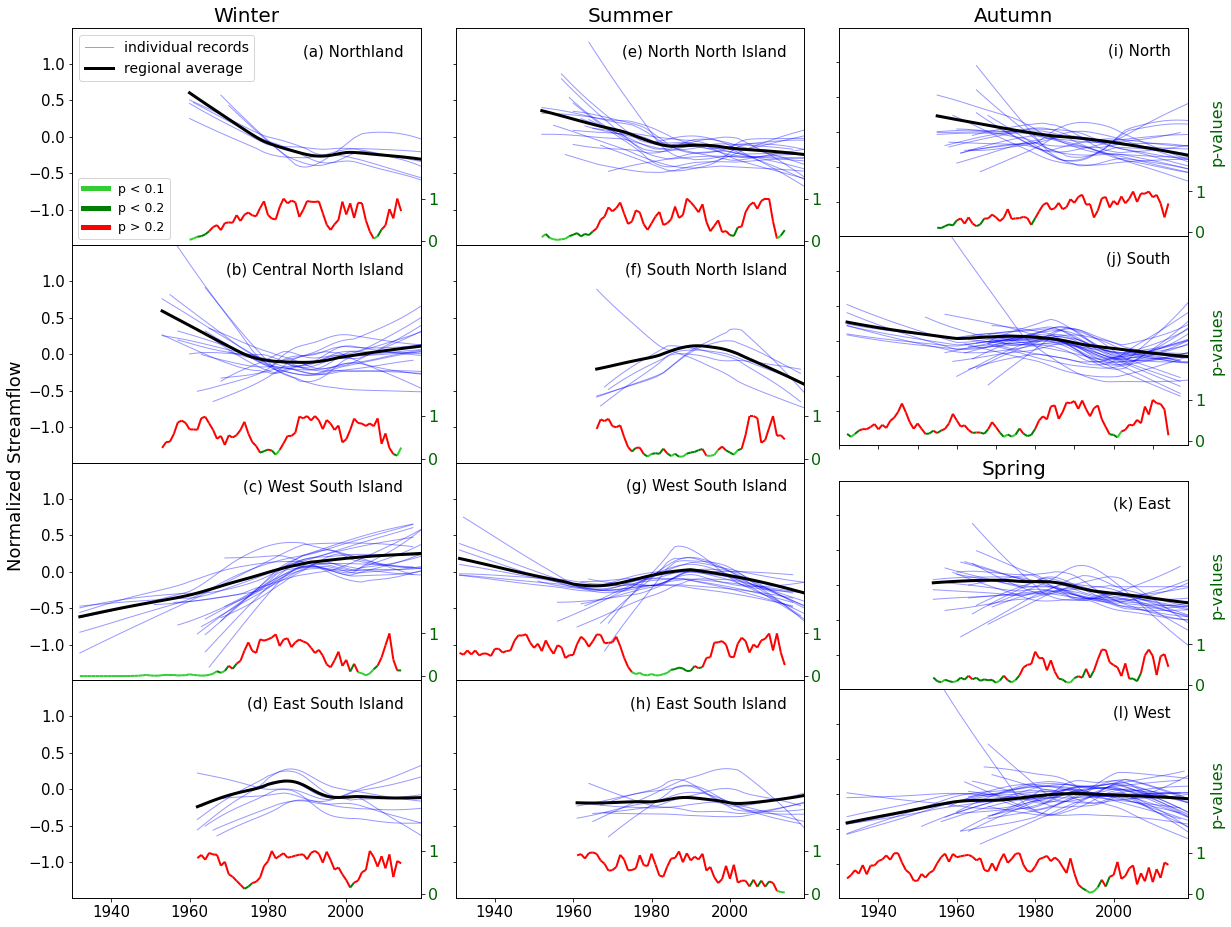

In [10]:

alpha = ['a','b','c','d','e','f','g','h','i','j','k','l','m','n']

seasons = [winter,spring,summer,autumn]
season_names = [winter_names,spring_names,summer_names,autumn_names]

n = 24

fig = plt.figure(figsize=(20,16))
spec = gridspec.GridSpec(ncols=3, nrows=n*4, wspace=.1, hspace=0,figure=fig)

axs = []
for column in range(2):
    for row in range(4):
        ax = fig.add_subplot(spec[row*n:row*n+n,column])
        axs.append(ax)

for row in range(4):
    if row < 2:
        ax = fig.add_subplot(spec[row*(n-1):row*(n-1)+(n-1),2])
        axs.append(ax)
    else:
        ax = fig.add_subplot(spec[row*(n-1)+4:row*(n-1)+(n+3),2])
        axs.append(ax)
       
    
ax_c = 0
for s in [6,12,3,9]:
    cluster_dict = cluster_lists[s]
    cluster_names = names_list[s]
    df = flow_df[flow_df.index.month.isin([s])]
    
    for c in cluster_dict:

        cluster_df = df[[str(num) for num in cluster_dict[c]]]

        multiple_records_year = 0
        for i in range(len(cluster_df.index)):
            if np.count_nonzero(~np.isnan(cluster_df.iloc[i]))>2:
                multiple_records_year = str(cluster_df.index[i].year)
                break

        cluster_df = cluster_df[multiple_records_year:]
        #cluster_df = ((cluster_df - cluster_df['1979':'1999'].mean())/cluster_df['1979':'1999'].mean())*100
        cluster_df = ((cluster_df - cluster_df.mean())/cluster_df.std())

        for i,site in enumerate(cluster_df):
            vals = np.array(cluster_df[site].values)
            years = np.array(cluster_df[site].index.year.values)

            lowess_fit = sm.nonparametric.lowess(vals, years, frac= 2./3, it=3, missing='drop')

            #if site == '29224':
            #    axs[ax_c].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, c='magenta',alpha=0.4,label='individual records' if c ==1 and i == 0 else '') 
            #    continue
            #if site == '1043428':
            #    axs[ax_c].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, c='green',alpha=0.4,label='individual records' if c ==1 and i == 0 else '') 
            #    continue
            
            axs[ax_c].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=1, c='blue',alpha=0.4,label='individual records' if c ==1 and i == 0 else '') 
            
        averaged_cluster = cluster_df.mean(axis=1,skipna=True)
        vals = np.array(averaged_cluster.values)
        years = np.array(averaged_cluster.index.year.values)

        lowess_fit = sm.nonparametric.lowess(vals, years, frac= 2./3, it=3, missing='drop')

        axs[ax_c].plot(lowess_fit[:,0], lowess_fit[:,1], linewidth=3, color = 'black', label='regional average' if c ==1 else '')

        #axs[ax_c].text(1940,1,str(ax_c))
        
        p_years = []
        ps = []
        for start_year in cluster_df.index.year.tolist()[:-5]:

            averaged_subset = averaged_cluster[str(start_year):]
            
            vals = averaged_subset.values
            years = averaged_subset.index.year.values

            #coef, p = kendalltau(years,vals,nan_policy='omit',method='asymptotic')
            trend, h, p, z, Tau, s, var_s, slope, intercept = mk.original_test(vals)
            
            ps.append(p)
            p_years.append(start_year)


        ax2 = axs[ax_c].twinx()  # instantiate a second axes that shares the same x-axis

        x = np.array(p_years)
        y = np.array(ps)
        
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        z = [0, 0.1, 0.2, 1]
        cmap = ListedColormap(['limegreen', 'green', 'red'])
        norm = BoundaryNorm(z, cmap.N)
        lc = LineCollection(segments, cmap=cmap, norm=norm)
        lc.set_array(y)
        lc.set_linewidth(2)
        line = ax2.add_collection(lc)
            
        if ax_c in [8,9,10,11]:
            ax2.set_ylabel('p-values', color='darkgreen', fontdict=font)
            
        #if ax_c in [0,1,2,3]:
        #    axs[ax_c].set_ylabel('sormalized streamflow',fontdict=font)

        if ax_c not in [0,1,2,3]:
            plt.setp(axs[ax_c].get_yticklabels(),visible=False)
         
        if ax_c not in [3,7,11]:
            plt.setp(axs[ax_c].get_xticklabels(),visible=False)
            
        if ax_c == 0:
            axs[ax_c].legend(loc='upper left', prop={'size': 14})
            
            ax2.autoscale()

            def make_proxy(zvalue, scalar_mappable, **kwargs):
                color = scalar_mappable.cmap(scalar_mappable.norm(zvalue))
                return Line2D([0, 1], [0, 1], color=color, **kwargs)
            
            proxies = [make_proxy(item, lc, linewidth=5) for item in z]
            ax2.legend(proxies, ['p < 0.1', 'p < 0.2', 'p > 0.2'], loc='lower left', prop={'size': 12.5})

        ax2.set_ylim(-0.1,5)
        
        ax2.tick_params(axis='y', labelcolor='darkgreen')
        ax2.get_yaxis().set_ticks([0,1])
        ax2.tick_params(axis='y',labelsize=16)
        
        axs[ax_c].text(.95, .89, "(" + alpha[ax_c] + ") " + cluster_names[c], fontsize= 15, horizontalalignment="right", 
                      verticalalignment="center", transform=axs[ax_c].transAxes)

        #axs[ax_c].hlines(0,1932,2019,linestyles='dashed',linewidth=1,color='white')
        axs[ax_c].set_xlim(1930,2019)
        axs[ax_c].set_ylim(-1.49,1.49)
        
        #if ax_c == 0:
        #    lines, labels = axs[ax_c].get_legend_handles_labels()
        #    lines2, labels2 = ax2.get_legend_handles_labels()
        #    axs[ax_c].legend(lines + lines2, labels + labels2, loc='upper left')

        ax_c += 1

axs[0].set_title('Winter', fontsize=20)
axs[4].set_title('Summer', fontsize=20)
axs[8].set_title('Autumn', fontsize=20)
axs[10].set_title('Spring', fontsize=20)

fig.text(0.08, 0.5, 'Normalized Streamflow', va='center', rotation='vertical', fontsize=18)

for i in [0,1,2,3]:
    axs[i].tick_params(axis='y',labelsize=15)
for i in [3,7,11]:
    axs[i].tick_params(axis='x',labelsize=15)


plt.setp(axs[9].get_xticklabels(),visible=False)
        
plt.subplots_adjust(wspace=0, hspace=0)

#plt.savefig('Figure7.png',dpi=300,bbox_inches='tight')
